### **Imports**

In [178]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, fetch_lfw_people
from sklearn.preprocessing import StandardScaler
from typing import Dict, Tuple
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

### **Load data**

In [179]:
# Load Iris dataset
iris = load_iris()

In [180]:
# Load Wine dataset
wine = load_wine()

In [181]:
# Load LFW dataset (faces resized to 62x47 pixels)
lfw_people = fetch_lfw_people(min_faces_per_person=50, resize=0.4)

### **Task 1**

#### Creating 3D synthetic data on a plane, applying PCA to reduce to 2D, and visualizing both stages

In [182]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 100 points in 2D
X = np.random.rand(100, 2)

# Create a third dimension that is a linear combination of the first two with added noise
Z = 0.5 * X[:, 0] + 0.2 * X[:, 1] + np.random.normal(0, 0.02, size=100)

# Combine into a 3D dataset
X3D = np.column_stack((X, Z))

# Apply PCA to reduce from 3D to 2D
pca = PCA(n_components=2)
X2D = pca.fit_transform(X3D)

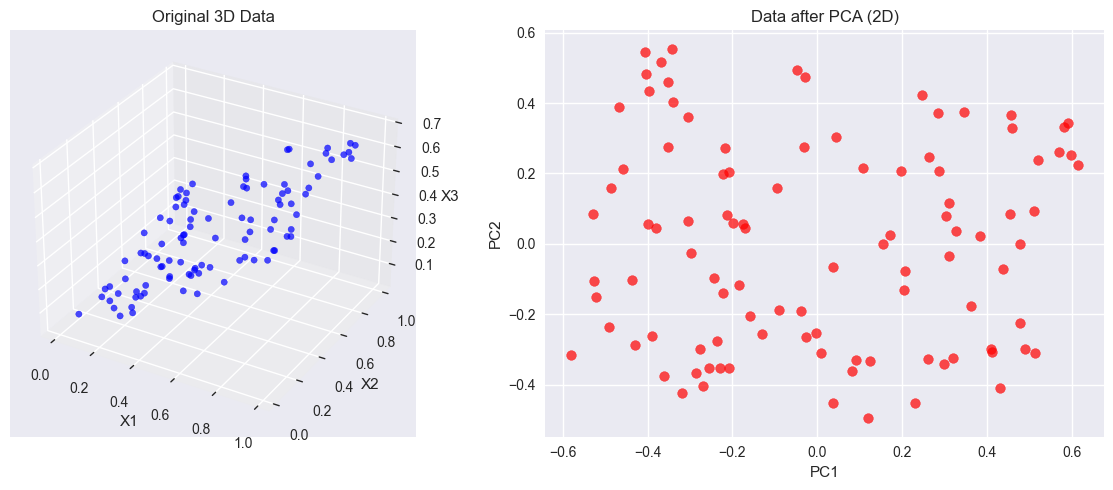

In [183]:
# Create visualizations
fig = plt.figure(figsize=(12, 5))

# Plot original 3D data
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(X3D[:, 0], X3D[:, 1], X3D[:, 2], c='blue', alpha=0.7)
ax.set_title('Original 3D Data')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')

# Plot reduced 2D data
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X2D[:, 0], X2D[:, 1], c='red', alpha=0.7)
ax2.set_title('Data after PCA (2D)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.tight_layout()

### **Task 2**

#### Performing PCA on the Iris dataset and plotting explained variance to determine number of components required for 95% variance

#### **Iris dataset**

In [184]:
# Work with iris dataset
X = iris.data
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [185]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Determine number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

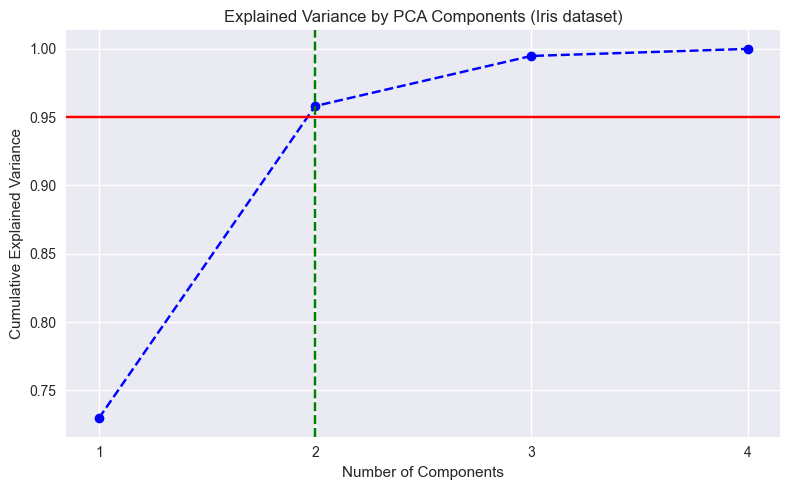

In [186]:
# Visualization
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='blue')
plt.axhline(y=0.95, color='red', linestyle='-')
plt.axvline(x=n_components_95, color='green', linestyle='--')
plt.title('Explained Variance by PCA Components (Iris dataset)', fontsize=12)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.tight_layout()

#### **Wine dataset**

In [187]:
# Work on wine dataset
X = wine.data
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [188]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Determine number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

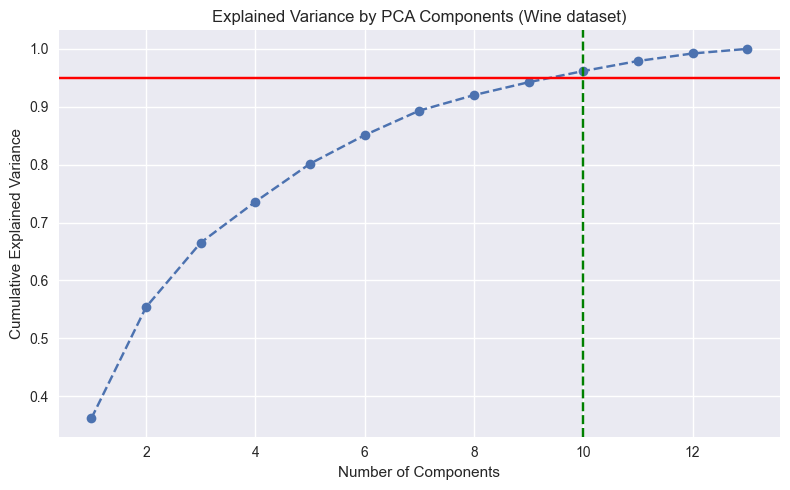

In [189]:
# Visualization
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axvline(x=n_components_95, color='g', linestyle='--')
plt.title('Explained Variance by PCA Components (Wine dataset)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()

### **Task 3**

#### Visualizing multidimensional data

In [190]:
def pca_2d_transform(X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray, PCA]:
    """
    Standardize features and reduce dimensionality to 2D using PCA.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix of shape (n_samples, n_features).
    y : np.ndarray
        Target vector of shape (n_samples,).

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, PCA]
        A tuple containing:
        - Z : np.ndarray
            2D PCA-transformed data of shape (n_samples, 2).
        - y : np.ndarray
            Unmodified target vector (returned for convenience in plotting).
        - pca : PCA
            Fitted PCA object (useful for explained variance, components, etc.).
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X_std)
    return Z, y, pca

In [191]:
def plot_pca_2d(Z: np.ndarray, y: np.ndarray, title: str, class_names: Tuple[str, ...]) -> None:
    """
    Plot a 2D scatter of PCA-transformed data colored by class.

    Parameters
    ----------
    Z : np.ndarray
        2D PCA-transformed data of shape (n_samples, 2).
    y : np.ndarray
        Class labels of shape (n_samples,).
    title : str
        Plot title.
    class_names : Tuple[str, ...]
        Class names corresponding to integer labels in y.
    """
    plt.figure(figsize=(7, 6))
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    for cls in np.unique(y):
        cls_mask = y == cls
        plt.scatter(
            Z[cls_mask, 0],
            Z[cls_mask, 1],
            s=40,
            alpha=0.8,
            c=colors[int(cls) % len(colors)],
            label=class_names[int(cls)],
            edgecolor="white",
            linewidth=0.7,
        )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend(title="Class", frameon=True)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

#### **Iris dataset**

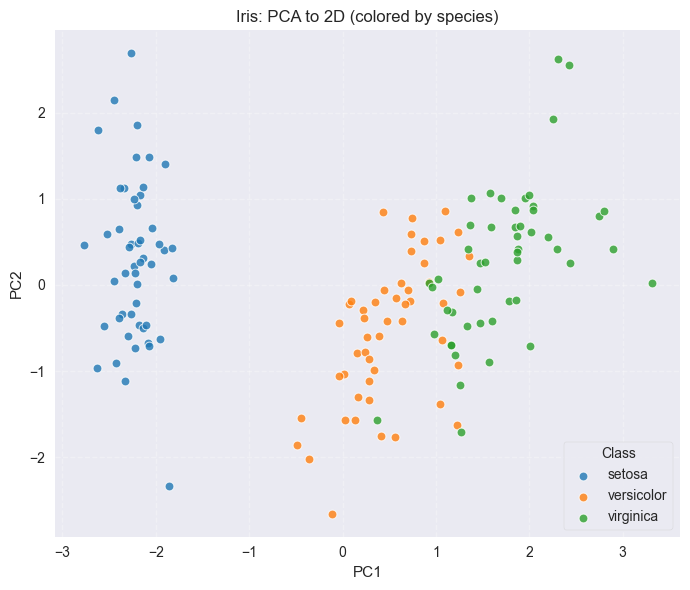

Iris: cumulative explained variance (2 PCs): 0.958


In [192]:
X_iris: np.ndarray = iris.data
y_iris: np.ndarray = iris.target
names_iris: Tuple[str, ...] = tuple(iris.target_names)

# PCA to 2D and plot
Z_iris, y_iris, pca_iris = pca_2d_transform(X_iris, y_iris)
plot_pca_2d(Z_iris, y_iris, title="Iris: PCA to 2D (colored by species)", class_names=names_iris)

# Quick interpretation printout
explained_iris = pca_iris.explained_variance_ratio_.sum()
print(f"Iris: cumulative explained variance (2 PCs): {explained_iris:.3f}")

#### **Wine dataset**

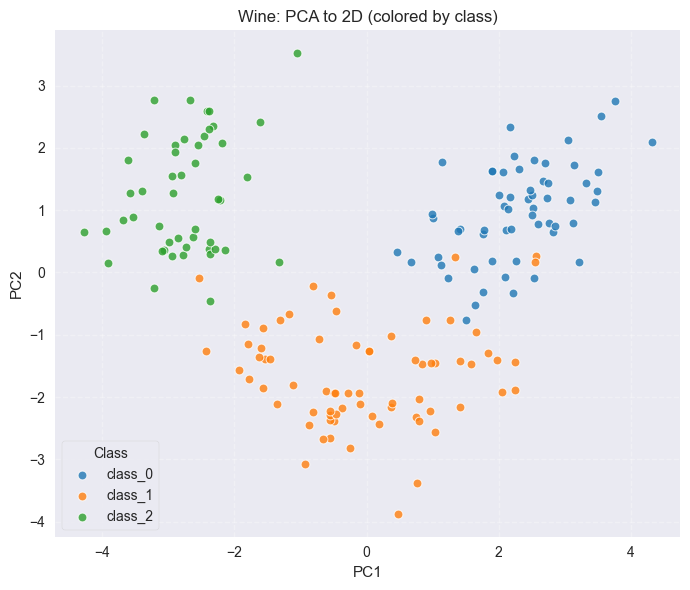

Wine: cumulative explained variance (2 PCs): 0.554


In [193]:
X_wine: np.ndarray = wine.data
y_wine: np.ndarray = wine.target
names_wine: Tuple[str, ...] = tuple(wine.target_names)

# PCA to 2D and plot
Z_wine, y_wine, pca_wine = pca_2d_transform(X_wine, y_wine)
plot_pca_2d(Z_wine, y_wine, title="Wine: PCA to 2D (colored by class)", class_names=names_wine)

# Quick interpretation printout
explained_wine = pca_wine.explained_variance_ratio_.sum()
print(f"Wine: cumulative explained variance (2 PCs): {explained_wine:.3f}")

#### **Conclusion:** Iris shows strong visual separation (especially setosa), so PCA is effective for 2D visualization. Wine’s variance is more distributed; 2D projection is informative but less separable, aligning with the need for more components to reach high explained variance.

### **Task 4**

#### Using PCA as preprocessing and comparing effectiveness with the Wine dataset

In [194]:
def benchmark_models(
    X: np.ndarray, y: np.ndarray, n_runs: int = 10
) -> Dict[str, Tuple[float, float]]:
    """
    Benchmark Logistic Regression and SVM classifiers on given data
    across multiple runs, returning average accuracy and training time.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix of shape (n_samples, n_features).
    y : np.ndarray
        Target vector of shape (n_samples,).
    n_runs : int, optional
        Number of repetitions for averaging results (default=10).

    Returns
    -------
    Dict[str, Tuple[float, float]]
        Dictionary mapping model names to (avg_accuracy, avg_training_time).
    """
    results: Dict[str, list] = {"LogReg": [], "SVM": []}

    for _ in range(n_runs):
        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y
        )

        # Logistic Regression
        start = time.time()
        log_reg = LogisticRegression(max_iter=500)
        log_reg.fit(X_train, y_train)
        train_time = time.time() - start
        acc = accuracy_score(y_test, log_reg.predict(X_test))
        results["LogReg"].append((acc, train_time))

        # SVM (linear kernel)
        start = time.time()
        svm = SVC(kernel="linear")
        svm.fit(X_train, y_train)
        train_time = time.time() - start
        acc = accuracy_score(y_test, svm.predict(X_test))
        results["SVM"].append((acc, train_time))

    # Average results
    avg_results: Dict[str, Tuple[float, float]] = {}
    for model, vals in results.items():
        accs, times = zip(*vals)
        avg_results[model] = (np.mean(accs), np.mean(times))

    return avg_results

In [195]:
# Work on wine dataset
X = wine.data
y = wine.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [196]:
# Case 1: Without PCA (all 13 features)
results_no_pca = benchmark_models(X_scaled, y, n_runs = 100)

In [197]:
# Case 2: With PCA (2 components only)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
results_pca = benchmark_models(X_pca, y, n_runs = 100)

In [198]:
# Print results
print("Average results without PCA (13 features):")
for model, (acc, t) in results_no_pca.items():
    print(f"{model}: Accuracy={acc:.3f}, Training time={t:.4f} sec")

print("\nAverage results with PCA (2 components):")
for model, (acc, t) in results_pca.items():
    print(f"{model}: Accuracy={acc:.3f}, Training time={t:.4f} sec")

Average results without PCA (13 features):
LogReg: Accuracy=0.979, Training time=0.0084 sec
SVM: Accuracy=0.962, Training time=0.0013 sec

Average results with PCA (2 components):
LogReg: Accuracy=0.961, Training time=0.0052 sec
SVM: Accuracy=0.961, Training time=0.0010 sec


#### **Conclusion:** In the case under study, the differences in benchmarks are small, but they can be significant in larger datasets. The accuracy after reduction to two dimensions is still satisfactory, with reduced training time for the models.

### **Task 5**

#### Linear Discriminant Analysis (LDA) vs PCA on the Wine dataset

In [199]:
# Wine dataset
X = wine.data
y = wine.target
class_names: Tuple[str, ...] = tuple(wine.target_names)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA reduction to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# LDA reduction to 2 components
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

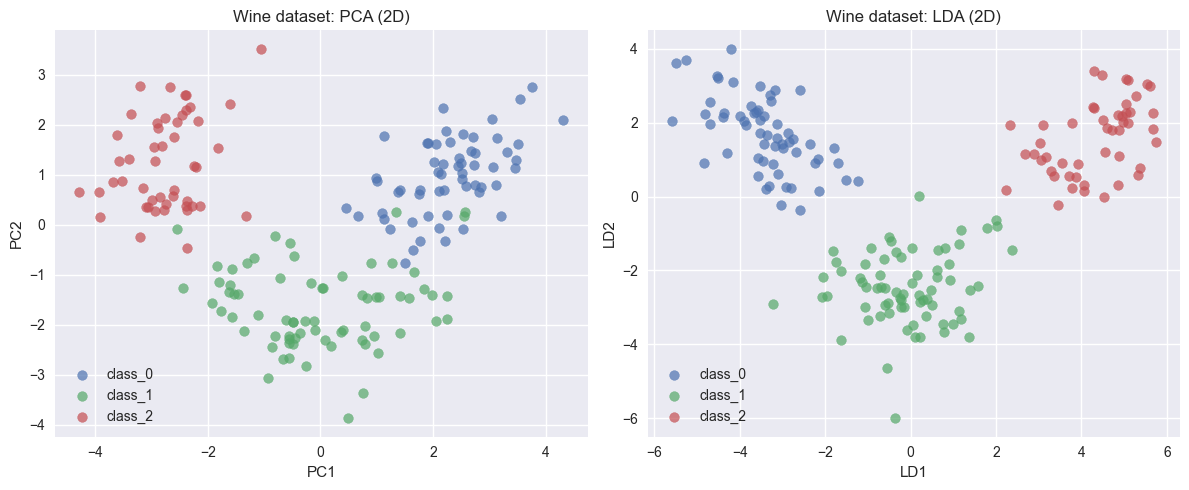

In [200]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCA plot
for cls in np.unique(y):
    axes[0].scatter(
        X_pca[y == cls, 0],
        X_pca[y == cls, 1],
        label=class_names[cls],
        alpha=0.7
    )
axes[0].set_title("Wine dataset: PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# LDA plot
for cls in np.unique(y):
    axes[1].scatter(
        X_lda[y == cls, 0],
        X_lda[y == cls, 1],
        label=class_names[cls],
        alpha=0.7
    )
axes[1].set_title("Wine dataset: LDA (2D)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].legend()

plt.tight_layout()
plt.show()

#### **Conclusions:** 
#### PCA (unsupervised): <br>Finds directions of maximum variance in the data, without considering class labels; <br>Good for dimensionality reduction and visualization, but clusters may overlap if variance is not aligned with class separation;<br>In Wine, PCA 2D shows partial separation, but classes overlap significantly.

#### LDA (supervised): <br>Maximizes class separability by finding linear combinations of features that best discriminate between classes;<br>Uses class labels during training;<br>In Wine, LDA 2D shows much clearer separation of the three classes compared to PCA.

#### PCA is best for general dimensionality reduction and visualization of variance structure. LDA is better for classification-oriented visualization, since it explicitly optimizes class separation. On Wine, LDA provides a more interpretable 2D plot for distinguishing classes, while PCA is less effective because variance is spread across many components.

### **Task 6**

#### LFW Faces: PCA reconstruction at different simplification levels

In [201]:
# Work on LFW data
X = lfw_people.data
images = lfw_people.images
h, w = images.shape[1], images.shape[2]

print(f"Dataset shape: {X.shape}, Image size: {h}x{w}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define PCA component levels
components_list = [300, 150, 50]

# Original number of components
components_original = h*w

Dataset shape: (1560, 1850), Image size: 50x37


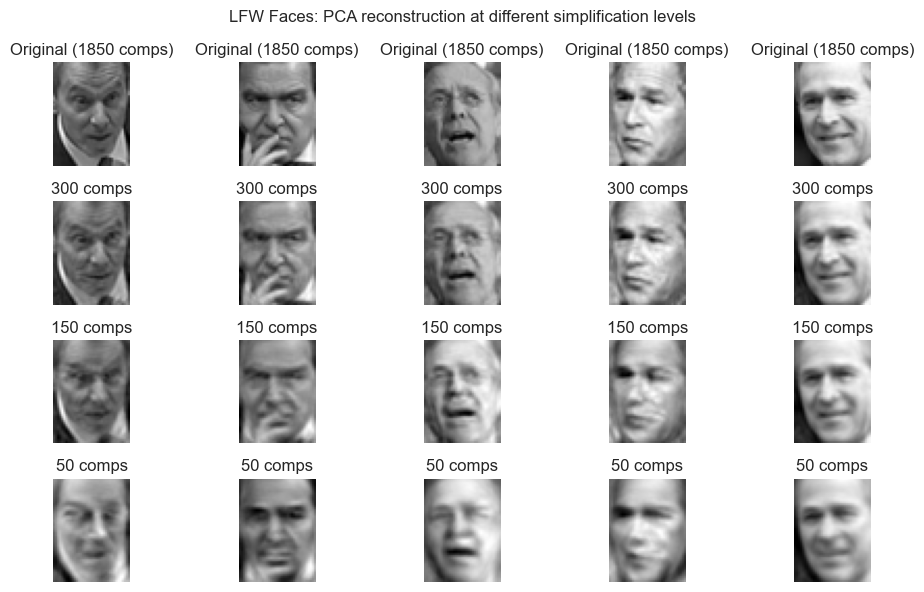

In [202]:
# Plot original + reconstructions
n_images = 5
fig, axes = plt.subplots(len(components_list)+1, n_images, figsize=(10, 6))

# Original images
for i in range(n_images):
    axes[0, i].imshow(images[i], cmap="gray")
    axes[0, i].set_title(f"Original ({components_original} comps)")
    axes[0, i].axis("off")

# PCA reconstructions
for row, n_comp in enumerate(components_list, start=1):
    pca = PCA(n_components=n_comp, whiten=True, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_pca)
    X_reconstructed = scaler.inverse_transform(X_reconstructed)

    for i in range(n_images):
        axes[row, i].imshow(X_reconstructed[i].reshape(h, w), cmap="gray")
        axes[row, i].set_title(f"{n_comp} comps")
        axes[row, i].axis("off")

plt.suptitle("LFW Faces: PCA reconstruction at different simplification levels")
plt.tight_layout()
plt.show()

#### **Conclusions:** PCA acts as lossy compression: fewer components result in stronger simplification and weaker reconstruction. For visualization, this experiment shows how much information is preserved at different compression levels.